Notebook 2: MOPA
===============================================================================

In [1]:
# import libraries
import sys
import copy
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(1, '../swa')

from geometry import *
from utils import *
from _stream import SeismicStream
from _curve import Curve

#import matplotlib
#matplotlib.use('Qt5Agg')

In [2]:
# Define the directories
method = 'mopa'
prj_dir = '../data/syn_data'

path2raw = os.path.join(prj_dir,'raw')
path2geom = f'{prj_dir}/geometry_test.csv' # Directory containing the geometry file
path2fk = f'{prj_dir}/proc/fk_filter' # Directory containing the FK filter file
path2disp = f'{prj_dir}/proc/mopa'

path2plot = 'figures/'
ext = '.sgy'  # Shot file extension
#filtname = 'fkfilter_synth_test.txt' # fk filter file
safe_makedirs(path2plot)

# List of directories to create
directories = [path2raw, path2geom, path2fk, path2disp, path2plot]
def create_dir(dir_list):
    for directory in dir_list:
        if not os.path.exists(directory):
            os.makedirs(directory)
            print(f"📁 Directory created: {directory}")
create_dir(directories)

📁 Directory created: ../data/syn_data/proc/mopa


In [3]:
# processing and plotting settings
settings = create_settings_dict(trafo = method,             # transformation type
                         zero_padding=True, freq_step=0.5,  # zero padding
                         normalize = True,local_max = True, # amplitude normalization
                         fmin=4, fmax=80,                  # frequency range
                         vmin=50, vmax=1000, velstep=1)     # testing phase velocity range and step


# get paths to shot files, survey geometry from geometry.csv
shot_files, source_coordinates, receiver_coordinates = read_geometry(path2geom)
path2sht = get_shotfiles_from_geometry(path2raw, shot_files, extension = ext, sort_ascending = False)

## 1. windowing

In [4]:
# define window length
win_len = 48

# define minimum and maximum accepted offsets
min_offset = .5
max_offset = 30

# increment with which the window moves
sr_move = 2

stream = SeismicStream(path2sht[0][0],      # shot file
                       settings,            # settings dict
                       path2geom,           # path to the geometry file
                       source_index = 0)    # source/shot index number
stream._check_traces()                      # remove traces where all amplitudes are zero

# windowing procedure
streams_dict = stream._windowing(path2disp,
                                  win_len,
                                  min_offset, max_offset,
                                  sr_move,
                                  fk_filter=True,          # some visualisation and processing options during windowing
                                  path2fk = path2fk + 'fkfilter_Shot_test.txt', #'../Rovereto/fkfilter_general.txt',
                                  show_FK = False,
                                  show_SFR = False,
                                  show_seismogram = False,
                                  show_spectrogram = False,
                                  show_previousDC=False,
                                  weighted = False,        # MOPA: unweighted/weighted LSQR
                                  rel_err = 5/100,         # MOPA: estimated relative error (used for weighting and abort criterion)
                                  stopAtChi2=2,            # MOPA: current stop criterion is the chi^2
                                  showMOPAResults = False, # MOPA: show interim MOPA results
                                  )

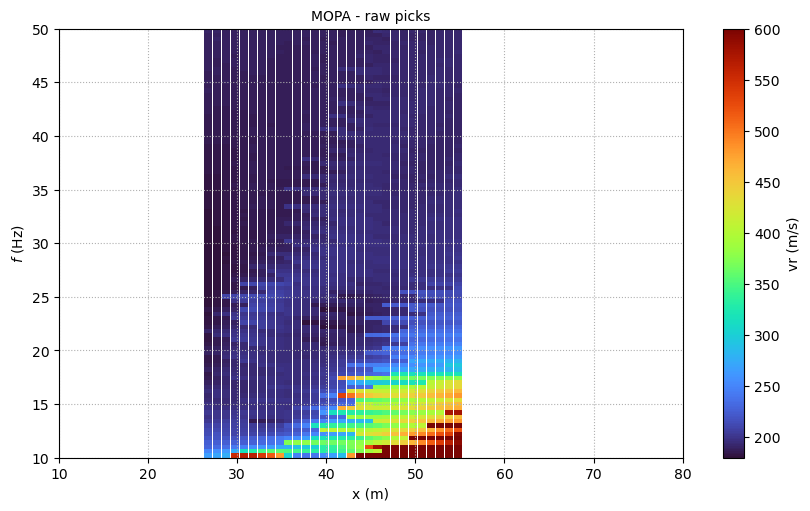

In [5]:
%matplotlib inline
# read the dispersion curve data and plot the 2D pseudosection
path2csv = '0_csv'
subfolders = [f.path for f in os.scandir(path2disp) if (f.is_dir())]
subfolders = natural_sort(subfolders)[:-1]

vmin = 180
vmax = 600

fig,ax = plt.subplots(figsize=(8, 5), constrained_layout = True)

for i,subfolder in enumerate(subfolders):

    dir = os.path.join(subfolder, path2csv)
    _, sf = os.path.split(subfolders[i])
    xmid = float(sf)

    if os.path.isdir(dir):
        for fname in os.listdir(dir):

            curve = Curve()
            curve._read(os.path.join(dir, fname))
            curve._plotColumn(axes = ax,
                          xmid = xmid,
                          vmin = vmin, vmax = vmax,
                          cmap = 'turbo', y_value = 'f',
                          width = .9,)

plot_colorBar(ax, vmin, vmax, cmap='turbo', orientation='vertical')
ax.set_xlim([10,80])
ax.set_ylim([10,50])
#ax.invert_yaxis()

ax.set_title('MOPA - raw picks', fontsize=10)
fig.savefig(os.path.join(path2plot,'3_mopa.png'), dpi=200)
plt.show()